In [1]:
import torch
from src.Architecture.GPTModel import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,  # we shorten the length from 1,024 to 256
    "embedding_dim": 768,
    "num_layers": 12,
    "num_heads": 12,
    "dropout": 0.1,         # It is possible and common to set dropout to 0.0
    "attention_dropout": 0.1,
    "ffn_dropout": 0.1,
    "qkv_bias": False,
}
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query)

In [2]:
import tiktoken
from src.Utilities.GenerationUtilities import generate_text_simple, text_to_token_ids, token_ids_to_text

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text: \n", token_ids_to_text(token_ids, tokenizer))

Output text: 
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


Clearly, the model isn’t yet producing coherent text because it hasn’t undergone training. To define what makes text “coherent” or “high quality,” we have to implement a numerical method to evaluate the generated content. This approach will enable us to monitor and enhance the model’s performance throughout its training process.

Next, we will calculate a loss metric for the generated outputs. This loss serves as a progress and success indicator of the training progress. Furthermore, in later chapters, when we fine-tune our LLM, we will review additional methodologies for assessing model quality.

### Calculating the text generation loss

Next, let’s explore techniques for numerically assessing text quality generated during training by calculating a text generation loss.

The goal of training an LLM is to maximize the likelihood of the correct token, which involves increasing its probability relative to other tokens. This way, we ensure the
LLM consistently picks the target token—essentially the next word in the sentence—as the next token it generates.

Let's walk through a basic example to get comfortable with how loss is calculated. There are 6 steps.

First, imagine we have two training batches that list the tokenId of the inputs and resulting targets:

In [3]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                        [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                [1107, 588, 11311]])  #  " really like chocolate"]

#### (Loss Calculation) Step 1: Compute logits & Step 2: Compute Probabilities of logits

In [4]:
with torch.no_grad():
    logits = model(inputs)
probs = torch.softmax(logits, dim=-1)
print(probs.shape)

torch.Size([2, 3, 50257])


The first number, 2, corresponds to the two examples (rows) in the inputs, also known as batch size. The second number, 3, corresponds to the number of tokens in each
input (row). Finally, the last number corresponds to the embedding dimensionality, which is determined by the vocabulary size. Following the conversion from logits to
probabilities via the softmax function, the generate_text_simple function then converts the resulting probability scores back into text.

We can complete steps 3 and 4 by applying the argmax function to the probability
scores to obtain the corresponding token IDs:

In [5]:
token_ids = torch.argmax(probs, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


Given that we have two input batches, each containing three tokens, applying the argmax function to the probability scores yields two sets of outputs, each with three predicted token IDs.

In [6]:
print(f"Targets input batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:", f"{token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets input batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


When we decode these tokens, we find that these output tokens are quite different from the target tokens we want the model to generate.

The model produces random text that is different from the target text because it has not been trained yet. We now want to evaluate the performance of the model’s generated text numerically via a loss. Not only is this useful for measuring the quality of the generated text, but it’s also a building block for implementing the training function, which we will use to update the model’s weight to improve the generated text.

 The model training aims to increase the softmax probability in the index positions corresponding to the correct target token IDs. This softmax probability is also used in the evaluation metric we will implement next to numerically assess the model’s generated outputs: the higher the probability in the correct positions, the better.

Remember the vocabulary we are using for our GPT-2 model has 50,257 tokens, so most of the initial probabilities will hover around 0.00002 (1/50,257).

For each of the two input texts, we can print the initial softmax probability scores corresponding to the target tokens using the following code:

#### (Loss Calculation) Step 3: Compute target probabilities

In [7]:
text_idx = 0
target_probs_1 = probs[text_idx, [0, 1, 2], targets[text_idx]]
print("Probabilities of the correct target tokens:")
print("Text 1:", target_probs_1)
text_idx = 1
target_probs_2 = probs[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probs_2)

Probabilities of the correct target tokens:
Text 1: tensor([7.4536e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6771e-05, 4.7559e-06])


The goal of training an LLM is to maximize the likelihood of the correct token, which
involves increasing its probability relative to other tokens. This way, we ensure the
LLM consistently picks the target token—essentially the next word in the sentence—
as the next token it generates.

#### (Loss Calculation) Step 4: Compute Log probabilities

Next we apply the logarithm to the probability scores. Working with logarithms of probability scores is more manageable in mathematical optimization than handling the scores directly:

In [8]:
log_probs = torch.log(torch.cat((target_probs_1, target_probs_2)))
print("Log probabilities: ", log_probs)

Log probabilities:  tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7765, -12.2561])


#### (Loss Calculation)  Step 5: Compute Avg log probability

 Next, we combine these log probabilities into a single score by computing the average:

In [9]:
avg_log_probs = torch.mean(log_probs)
print("Average log probability: ", avg_log_probs)

Average log probability:  tensor(-10.7940)


#### (Loss Calculation) Step 6: Multiply by -1

The goal is to get the average log probability as close to 0 as possible by updating the model’s weights as part of the training process. However, in deep learning, the common practice isn’t to push the average log probability up to 0 but rather to bring the negative average log probability down to 0. The negative average log probability is simply the average log probability multiplied by –1.

In [10]:
neg_avg_log_probs = avg_log_probs * -1
print("Negative avg log probability (aka Cross Entropy): ",neg_avg_log_probs)

Negative avg log probability (aka Cross Entropy):  tensor(10.7940)


In deep learning, the term for turning this negative value, –10.7940, into 10.7940, is known as the cross entropy loss. PyTorch comes in handy here, as it already has a built-in cross_entropy function that takes care of all these six steps for us.

Before we apply the cross_entropy function, let’s briefly recall the shape of the logits and target tensors:

In [11]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


As we can see, the logits tensor has three dimensions: batch size, number of tokens, and vocabulary size. The targets tensor has two dimensions: batch size and number of tokens.

For the cross_entropy loss function in PyTorch, we want to flatten these tensors by combining them over the batch dimension:

In [12]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


Remember that the targets are the token IDs we want the LLM to generate, and the logits contain the unscaled model outputs before they enter the softmax function to obtain the probability scores.

Previously, we applied the softmax function, selected the probability scores corresponding to the target IDs, and computed the negative average log probabilities. PyTorch’s cross_entropy function will take care of all these steps for us:

In [13]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print("Cross entropy loss: ", loss)

Cross entropy loss:  tensor(10.7940)


The resulting loss is the same that we obtained previously when applying the individual steps.


#### Perplexity

Perplexity is a measure often used alongside cross entropy loss to evaluate the performance of models in tasks like language modeling. It can provide a more interpretable way to understand the uncertainty of a model in predicting the next token in a sequence.

Perplexity measures how well the probability distribution predicted by the model matches the actual distribution of the words in the dataset. Similar to the loss, a lower perplexity indicates that the model predictions are closer to the actual distribution.

Perplexity can be calculated as perplexity = torch.exp(loss), which returns tensor(48725.8203) when applied to the previously calculated loss.

Perplexity is often considered more interpretable than the raw loss value because it signifies the effective vocabulary size about which the model is uncertain at each step. In the given example, this would translate to the model being unsure about which among 48,725 tokens in the vocabulary to generate as the next token.

We have now calculated the loss for two small text inputs for illustration purposes.
Next, we will apply the loss computation to the entire training and validation sets.

### Calculating the training and validation set losses

We must first prepare the training and validation datasets that we will use to train the
LLM.

To compute the loss on the training and validation datasets, we use a very small text
dataset, the “The Verdict” short story by Edith Wharton, which we have already
worked with in chapter 2. By selecting a text from the public domain, we circumvent
any concerns related to usage rights. Additionally, using such a small dataset allows
for the execution of code examples on a standard laptop computer in a matter of

NOTE: Interested readers can also use the supplementary code for this book to prepare a larger-scale dataset consisting of more than 60,000 public domain books from Project Gutenberg and train an LLM on these (see appendix D for details).

#### The cost of pretraining LLMs

To put the scale of our project into perspective, consider the training of the 7 billion parameter Llama 2 model, a relatively popular openly available LLM. This model
required 184,320 GPU hours on expensive A100 GPUs, processing 2 trillion tokens.

At the time of writing, running an 8 × A100 cloud server on AWS costs around 30 dollars per hour. A rough estimate puts the total training cost of such an LLM at around $690,000 (calculated as 184,320 hours divided by 8, then multiplied by 30 dollars per hour).

NOTE We are training the model with training data presented in similarly
sized chunks for simplicity and efficiency. However, in practice, it can also be
beneficial to train an LLM with variable-length inputs to help the LLM to bet
ter generalize across different types of inputs when it is being used.

To implement the data splitting and loading, we first define a train_ratio to use 90%
of the data for training and the remaining 10% as validation data for model evaluation during training:

In [14]:
file_path = "data/the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

In [15]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [16]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [17]:
from src.Utilities.DataProcessing import create_dataloader_v1

torch.manual_seed(123)
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    number_of_workers=0
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    number_of_workers=0
)

We used a relatively small batch size to reduce the computational resource demand because we were working with a very small dataset. In practice, training LLMs with batch sizes of 1,024 or larger is not uncommon.

As an optional check, we can iterate through the data loaders to ensure that they
were created correctly:

In [18]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


Based on the preceding code output, we have nine training set batches with two samples and 256 tokens each.

Since we allocated only 10% of the data for validation, there is only one validation batch consisting of two input examples. As expected, the input data (x) and target data (y) have the same shape (the batch size times the number of tokens in each batch) since the targets are the inputs shifted by one position.

Next, we implement a utility function to calculate the cross entropy loss of a given batch returned via the training and validation loader:

In [19]:
from src.Utilities.TrainingUtilities import calc_loss_batch, calc_loss_loader

We can now use this calc_loss_batch utility function, which computes the loss for a
single batch, to implement the following calc_loss_loader function that computes
the loss over all the batches sampled by a given data loader.

In [20]:
selected_device = "cuda" if torch.cuda.is_available() else "cpu"
print("Selected device:", selected_device)

Selected device: cuda


In [21]:
import torch

print("PyTorch version:", torch.__version__)
print("PyTorch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.9.0+cu128
PyTorch CUDA build: 12.8
CUDA available: True
GPU count: 1
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [22]:
device = torch.device(selected_device)
model.to(device)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.98758273654514
Validation loss: 10.98110580444336


The loss values are relatively high because the model has not yet been trained. For comparison, the loss approaches 0 if the model learns to generate the next tokens as they appear in the training and validation sets.

Now that we have a way to measure the quality of the generated text, we will train the LLM to reduce this loss so that it becomes better at generating text.

### Training an LLM

It is finally time to implement the code for pretraining the LLM, our GPTModel. For this, we focus on a straightforward training loop to keep the code concise and readable.

NOTE Interested readers can learn about more advanced techniques, including learning rate warmup, cosine annealing, and gradient clipping, in appendix D.

8 steps to training an LLM: starting with iterating over each epoch, processing batches, resetting gradients, calculating the loss and new gradients, and updating weights and concluding with monitoring steps like printing losses and generating text samples.

We can implement this training flow via the train_model_simple function in code:

In [23]:
from src.Utilities.TrainingUtilities import train_model_simple

Let’s see this all in action by training a GPTModel instance for 10 epochs using an AdamW optimizer and the train_model_simple function we defined earlier:

In [24]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
     model.parameters(),
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.825, Val loss 9.931
Ep 1 (Step 000005): Train loss 8.069, Val loss 8.341
Every effort moves you,,,,,,,,,,,,,,.                                   
Ep 2 (Step 000010): Train loss 6.625, Val loss 7.051
Ep 2 (Step 000015): Train loss 6.048, Val loss 6.599
Every effort moves you, and,, and,,,,,,,,,.                                   
Ep 3 (Step 000020): Train loss 5.575, Val loss 6.494
Ep 3 (Step 000025): Train loss 5.505, Val loss 6.413
Every effort moves you, and, and, and, and, and, and, and of the of the of the of the to to to the to to the of the of the of the of the of the's, and, and, and, and, and
Ep 4 (Step 000030): Train loss 5.080, Val loss 6.323
Ep 4 (Step 000035): Train loss 4.839, Val loss 6.316
Every effort moves you a the picture. I had been the picture. I had a.              "I had been the of the picture.             
Ep 5 (Step 000040): Train loss 4.226, Val loss 6.180
Every effort moves you know the fact of the "--I looked--and a little o

As we can see, the training loss improves drastically, starting with a value of 9.781 and converging to 0.391. The language skills of the model have improved quite a
lot. In the beginning, the model is only able to append commas to the start context (Every effort moves you,,,,,,,,,,,,) or repeat the word and. At the end of the training, it can generate grammatically correct text.

Similar to the training set loss, we can see that the validation loss starts high (9.933) and decreases during the training. However, it never becomes as small as the training set loss and remains at 6.452 after the 10th epoch.

Before discussing the validation loss in more detail, let’s create a simple plot that shows the training and validation set losses side by side:

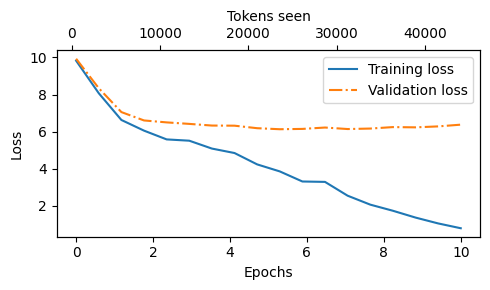

In [25]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

The resulting training and validation loss plot is shown in figure 5.12. As we can see, both the training and validation losses start to improve for the first epoch. However, the losses start to diverge past the second epoch. This divergence and the fact that the validation loss is much larger than the training loss indicate that the model is overfitting to the training data. We can confirm that the model memorizes the training data verbatim by searching for the generated text snippets, such as quite insensible to the irony in the “The Verdict” text file.

This memorization is expected since we are working with a very, very small training dataset and training the model for multiple epochs. Usually, it’s common to train a model on a much larger dataset for only one epoch.

### Decoding strategies to control randomness